In [5]:
import numpy as np
arr = np.load("zarr_image.npy") / 256
arr2 = np.load("tif_image.npy")

arr2 = (arr2 - arr2.min())
arr2 =  arr2 / arr2.max()

In [6]:
arr.min(), arr.max()

(0.0390625, 0.984375)

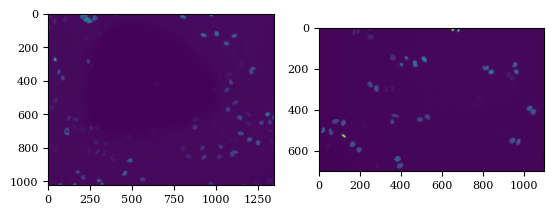

In [7]:
import matplotlib.pyplot as plt

fix, ax = plt.subplots(1,2)

ax.flat[0].imshow(arr)
ax.flat[1].imshow(arr2)

## New

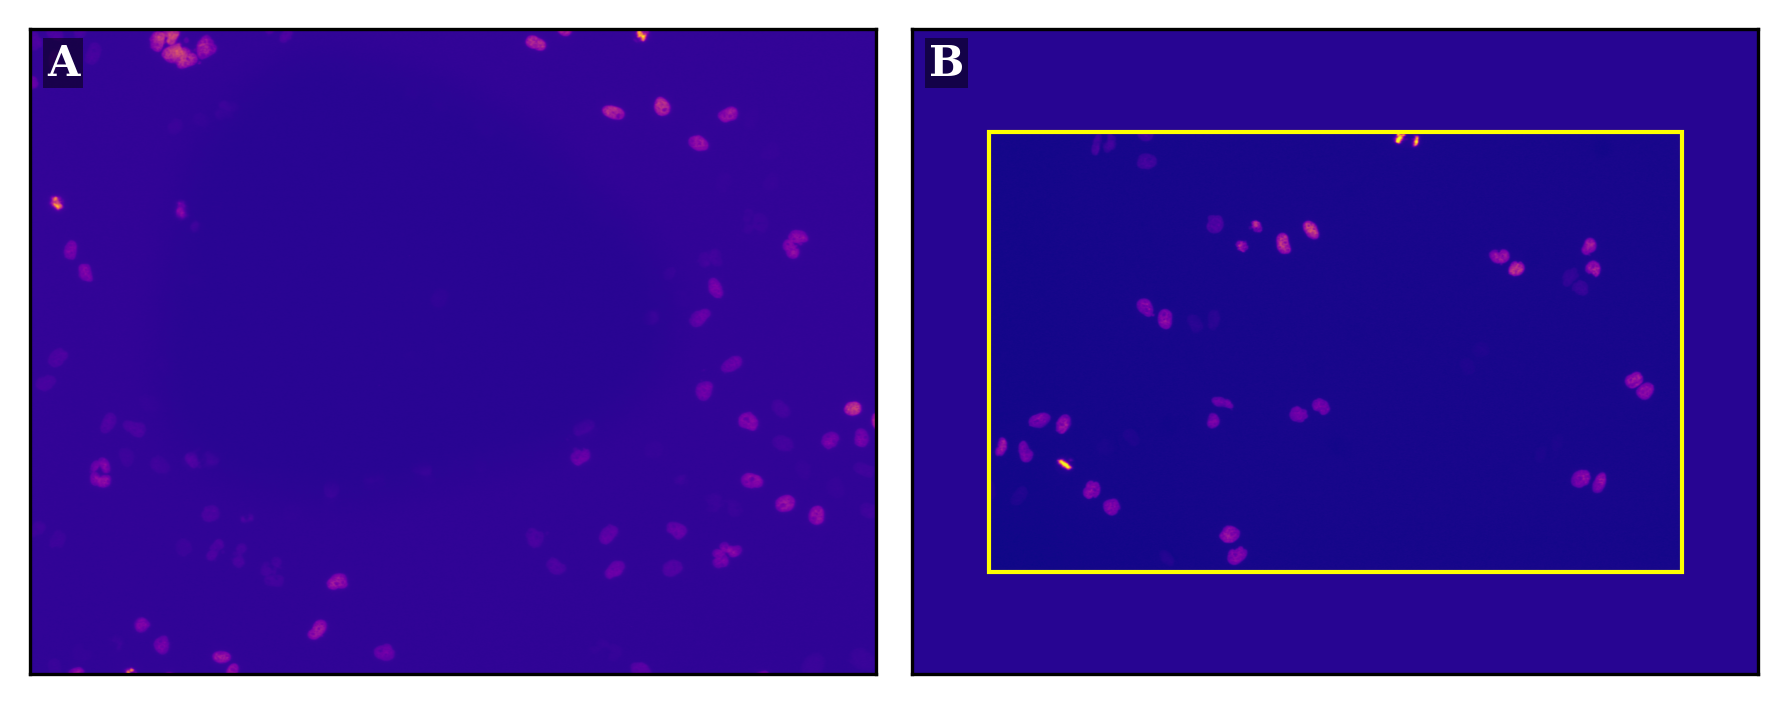

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# INPUT IMAGES (YOUR ARRAYS)
# ------------------------------------------------------------
# arr  = full-resolution image, shape (H, W)
# arr2 = center-crop of arr, smaller

H, W = arr.shape[:2]
h2, w2 = arr2.shape[:2]

# ------------------------------------------------------------
# COMPUTE CENTERED PADDING FOR arr2
# ------------------------------------------------------------
pad_top    = (H - h2) // 2
pad_bottom = H - h2 - pad_top
pad_left   = (W - w2) // 2
pad_right  = W - w2 - pad_left

# Pad using a constant value (e.g., zero or edge value)
pad_value = np.percentile(arr, 1)  # low-intensity value for contrast
arr2_padded = np.pad(
    arr2,
    ((pad_top, pad_bottom), (pad_left, pad_right)),
    mode="constant",
    constant_values=pad_value,
)

# ------------------------------------------------------------
# GLOBAL STYLE
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ------------------------------------------------------------
# FIGURE (2 PANELS: FULL IMAGE AND PADDED CROP)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=300)

vmin, vmax = 0, 1

# ------------------------------------------------------------
# LEFT: ORIGINAL FULL IMAGE
# ------------------------------------------------------------
ax0 = axes[0]
ax0.imshow(arr, cmap="plasma", vmin=vmin, vmax=vmax)
ax0.set_xticks([])
ax0.set_yticks([])
ax0.text(
    0.02, 0.98, "A",
    transform=ax0.transAxes,
    ha="left", va="top",
    fontsize=10, fontweight="bold",
    color="white",
    bbox=dict(boxstyle="square,pad=0.1", fc="black", ec="none", alpha=0.5),
)

# ------------------------------------------------------------
# RIGHT: PADDED CENTER CROP
# ------------------------------------------------------------
ax1 = axes[1]
ax1.imshow(arr2_padded, cmap="plasma", vmin=vmin, vmax=vmax)
ax1.set_xticks([])
ax1.set_yticks([])

ax1.text(
    0.02, 0.98, "B",
    transform=ax1.transAxes,
    ha="left", va="top",
    fontsize=10, fontweight="bold",
    color="white",
    bbox=dict(boxstyle="square,pad=0.1", fc="black", ec="none", alpha=0.5),
)

# ------------------------------------------------------------
# OPTIONAL: OUTLINE THE TRUE CROP REGION
# ------------------------------------------------------------
import matplotlib.patches as patches

rect = patches.Rectangle(
    (pad_left, pad_top),
    w2, h2,
    linewidth=1,
    edgecolor="yellow",
    facecolor="none",
)
ax1.add_patch(rect)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
plt.tight_layout()
fig.savefig("mitocheck_center_crop_comparison.pdf", bbox_inches="tight")
plt.show()
